In [ ]:
# 1) Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import (train_test_split, GridSearchCV,
                                     cross_validate, StratifiedKFold)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.impute import SimpleImputer
from sklearn.metrics import (accuracy_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix,
                              ConfusionMatrixDisplay, RocCurveDisplay)

In [ ]:
# 2) Mount Google Drive and load dataset
from google.colab import drive
drive.mount("/content/drive")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#loading the data
# Data Source: https://www.kaggle.com/datasets/sid321axn/heart-statlog-cleveland-hungary-final/data

data_path = '/content/drive/MyDrive/Heart Disease Dataset UCI/heart_statlog_cleveland_hungary_final.xls'

df = pd.read_csv(data_path)
print("Shape:", df.shape)
df.head()

Shape: (1190, 12)


,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,40,1,2,140,289,0,0,172,0,0.0,1,0
1,49,0,3,160,180,0,0,156,0,1.0,2,1
2,37,1,2,130,283,0,1,98,0,0.0,1,0
3,48,0,4,138,214,0,0,108,1,1.5,2,1
4,54,1,3,150,195,0,0,122,0,0.0,1,0


In [ ]:
# 3) Basic structure checks
print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nDtypes:\n", df.dtypes)

Shape: (1190, 12)

Columns:
 ['age', 'sex', 'chest pain type', 'resting bp s', 'cholesterol', 'fasting blood sugar', 'resting ecg', 'max heart rate', 'exercise angina', 'oldpeak', 'ST slope', 'target']

Dtypes:
 age                      int64
sex                      int64
chest pain type          int64
resting bp s             int64
cholesterol              int64
fasting blood sugar      int64
resting ecg              int64
max heart rate           int64
exercise angina          int64
oldpeak                float64
ST slope                 int64
target                   int64
dtype: object


In [ ]:
# 4) Check missing values and duplicates
print("Missing values per column:\n", df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Missing values per column:
 age                    0
sex                    0
chest pain type        0
resting bp s           0
cholesterol            0
fasting blood sugar    0
resting ecg            0
max heart rate         0
exercise angina        0
oldpeak                0
ST slope               0
target                 0
dtype: int64

Duplicate rows: 272


In [ ]:
# 5) Remove exact duplicate rows
df_clean = df.drop_duplicates().reset_index(drop=True)

print("Original shape :", df.shape)
print("Cleaned shape  :", df_clean.shape)
print("Rows removed   :", df.shape[0] - df_clean.shape[0])
print("Remaining duplicates:", df_clean.duplicated().sum())

Original shape : (1190, 12)
Cleaned shape  : (918, 12)
Rows removed   : 272
Remaining duplicates: 0


In [ ]:
# 7) Define target and feature groups
target_col  = "target"
continuous  = ["age", "resting bp s", "cholesterol", "max heart rate", "oldpeak"]
categorical = ["sex", "chest pain type", "fasting blood sugar",
               "resting ecg", "exercise angina", "ST slope"]

print("Target        :", target_col)
print("Continuous    :", continuous)
print("Categorical   :", categorical)

Target        : target
Continuous    : ['age', 'resting bp s', 'cholesterol', 'max heart rate', 'oldpeak']
Categorical   : ['sex', 'chest pain type', 'fasting blood sugar', 'resting ecg', 'exercise angina', 'ST slope']


In [ ]:
# 8) Summary statistics — continuous features (before scaling)
print("=== Summary Statistics — Raw (Before Scaling) ===")
df[continuous].describe().T

=== Summary Statistics — Raw (Before Scaling) ===


,count,mean,std,min,25%,50%,75%,max
age,1190.0,53.720168,9.358203,28.0,47.0,54.0,60.00,77.0
resting bp s,1190.0,132.153782,18.368823,0.0,120.0,130.0,140.00,200.0
cholesterol,1190.0,210.363866,101.420489,0.0,188.0,229.0,269.75,603.0
max heart rate,1190.0,139.732773,25.517636,60.0,121.0,140.5,160.00,202.0
oldpeak,1190.0,0.922773,1.086337,-2.6,0.0,0.6,1.60,6.2


In [ ]:
# 9) Handle zero cholesterol
#    Replace 0s with NaN, then impute with median (robust to skew)
print("Zero cholesterol rows (before):", (df_clean['cholesterol'] == 0).sum())
print("Zero resting bp s rows        :", (df_clean['resting bp s'] == 0).sum())

df_clean['cholesterol']  = df_clean['cholesterol'].replace(0, np.nan)
df_clean['resting bp s'] = df_clean['resting bp s'].replace(0, np.nan)

# Impute with median
for col in ['cholesterol', 'resting bp s']:
    median_val = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_val)
    print(f"Imputed '{col}' NaNs with median = {median_val:.1f}")

print("\nMissing values after imputation:\n", df_clean.isna().sum())

Zero cholesterol rows (before): 0
Zero resting bp s rows        : 0
Imputed 'cholesterol' NaNs with median = 237.0
Imputed 'resting bp s' NaNs with median = 130.0

Missing values after imputation:
 age                    0
sex                    0
chest pain type        0
resting bp s           0
cholesterol            0
fasting blood sugar    0
resting ecg            0
max heart rate         0
exercise angina        0
oldpeak                0
ST slope               0
target                 0
dtype: int64


In [ ]:
# 10) Define target and feature groups
#target_col  = "target"
##continuous  = ["age", "resting bp s", "cholesterol", "max heart rate", "oldpeak"]
##categorical = ["sex", "chest pain type", "fasting blood sugar",
            #   "resting ecg", "exercise angina", "ST slope"]

#print("Target        :", target_col)
#print("Continuous    :", continuous)
#print("Categorical   :", categorical)

Target        : target
Continuous    : ['age', 'resting bp s', 'cholesterol', 'max heart rate', 'oldpeak']
Categorical   : ['sex', 'chest pain type', 'fasting blood sugar', 'resting ecg', 'exercise angina', 'ST slope']


In [ ]:
# 11) Unique values for categorical features
counts = df_clean[target_col].value_counts().sort_index()
for col in categorical:
    print(col, "->", sorted(df_clean[col].unique()))

sex -> [np.int64(0), np.int64(1)]
chest pain type -> [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
fasting blood sugar -> [np.int64(0), np.int64(1)]
resting ecg -> [np.int64(0), np.int64(1), np.int64(2)]
exercise angina -> [np.int64(0), np.int64(1)]
ST slope -> [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


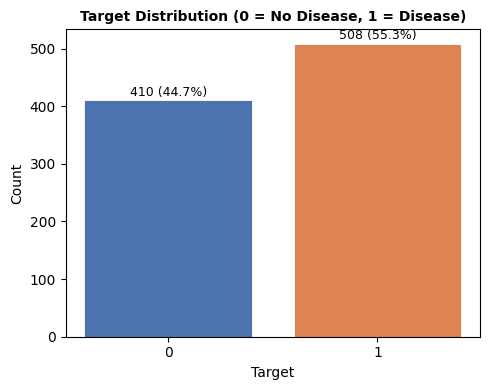

In [ ]:
# 12) Target distribution plot
plt.figure(figsize=(5, 4))
bars = plt.bar(counts.index.astype(str), counts.values,
               color=['#4C72B0', '#DD8452'], edgecolor='white', linewidth=0.6)
plt.title("Target Distribution (0 = No Disease, 1 = Disease)", fontsize=10, fontweight='bold')
plt.xlabel("Target")
plt.ylabel("Count")

total = counts.sum()
for bar in bars:
    height = bar.get_height()
    pct = (height / total) * 100
    plt.text(bar.get_x() + bar.get_width() / 2, height + 3,
             f"{int(height)} ({pct:.1f}%)", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

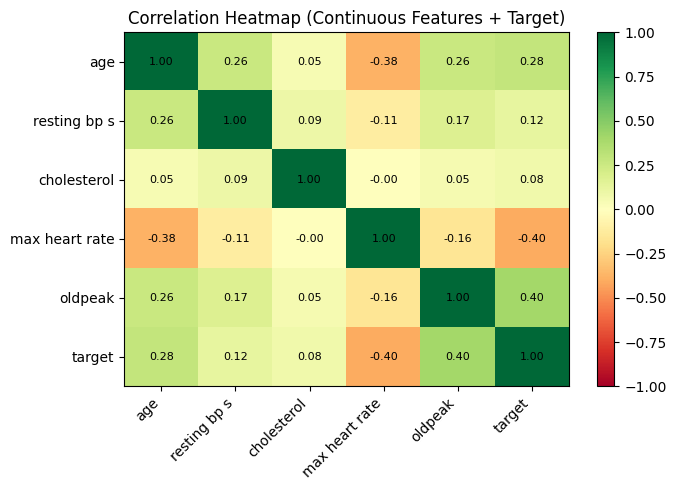

In [ ]:
# 11) Correlation heatmap — continuous features + target
corr = df_clean[continuous + [target_col]].corr(numeric_only=True)

plt.figure(figsize=(7, 5))
plt.imshow(corr.values, aspect="auto", cmap="RdYlGn", vmin=-1, vmax=1)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
plt.yticks(range(len(corr.index)), corr.index)
for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.values[i,j]:.2f}",
                 ha="center", va="center", fontsize=8)
plt.title("Correlation Heatmap (Continuous Features + Target)")
plt.colorbar()
plt.tight_layout()
plt.show()

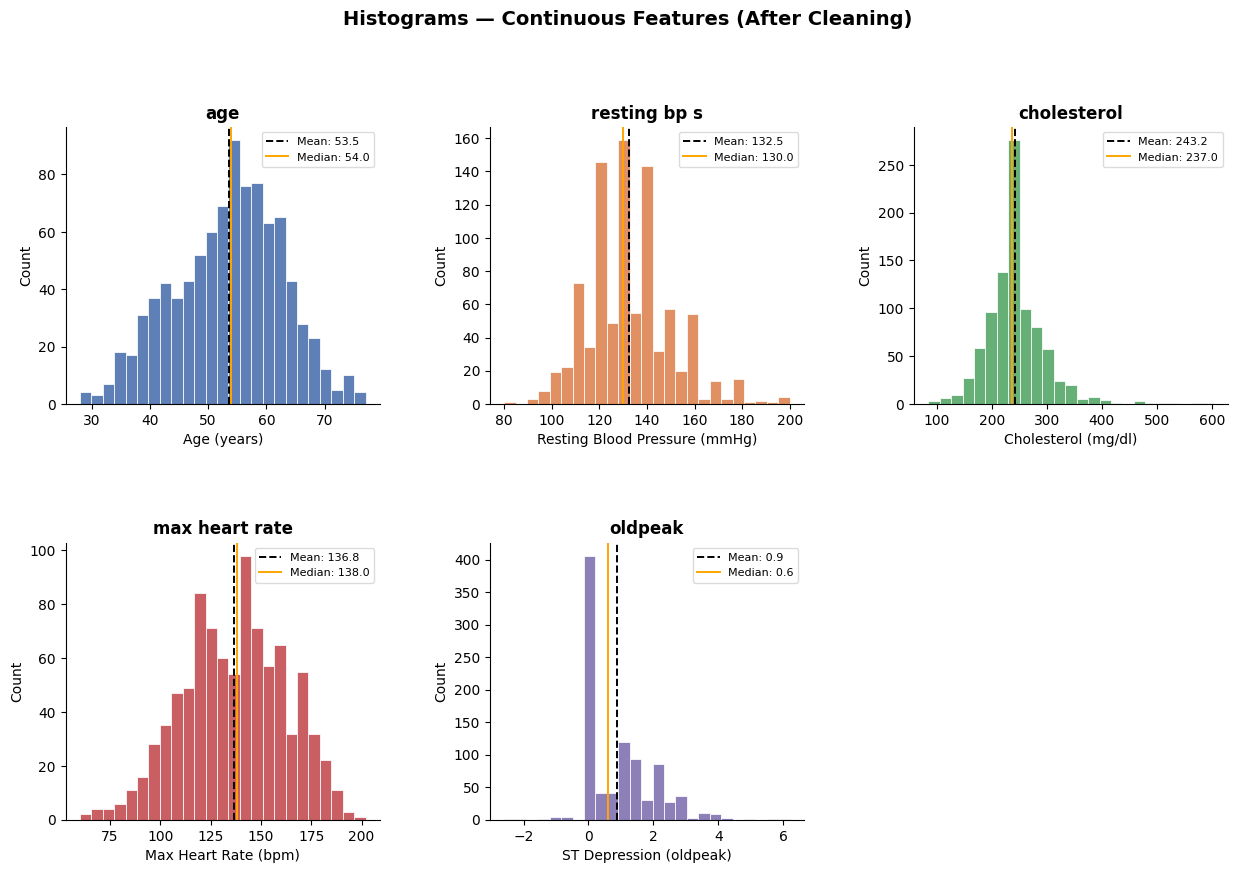

In [ ]:
# 12) Histograms — continuous features after cleaning
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

feat_labels = {
    "age":            "Age (years)",
    "resting bp s":   "Resting Blood Pressure (mmHg)",
    "cholesterol":    "Cholesterol (mg/dl)",
    "max heart rate": "Max Heart Rate (bpm)",
    "oldpeak":        "ST Depression (oldpeak)"
}
colors = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2']

for i, (col, color) in enumerate(zip(continuous, colors)):
    ax = axes[i]
    data = df_clean[col]
    ax.hist(data, bins=25, color=color, edgecolor='white', linewidth=0.6, alpha=0.90)
    ax.axvline(data.mean(),   color='black',  linestyle='--', linewidth=1.4,
               label=f'Mean: {data.mean():.1f}')
    ax.axvline(data.median(), color='orange', linestyle='-',  linewidth=1.4,
               label=f'Median: {data.median():.1f}')
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_xlabel(feat_labels[col], fontsize=10)
    ax.set_ylabel("Count", fontsize=10)
    ax.spines[['top','right']].set_visible(False)
    ax.legend(fontsize=8, framealpha=0.7)

axes[-1].set_visible(False)
fig.suptitle("Histograms — Continuous Features (After Cleaning)",
             fontsize=14, fontweight='bold', y=1.01)
plt.subplots_adjust(hspace=0.50, wspace=0.35)
plt.show()

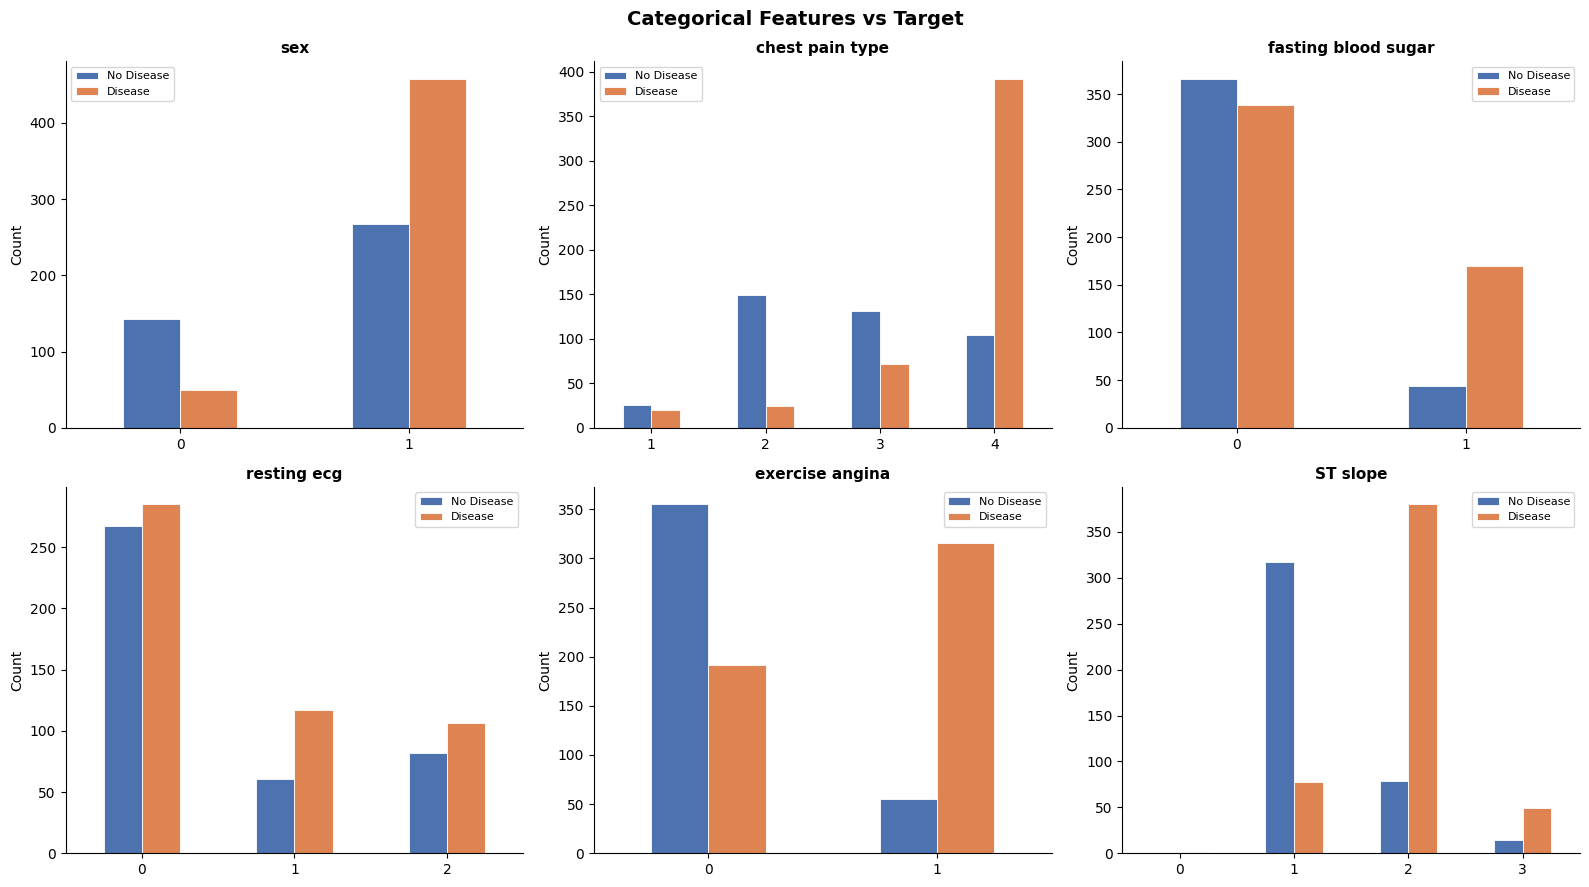

In [ ]:
# 13) Categorical feature distributions vs target
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

cat_labels = {
    "sex":                 ["Female", "Male"],
    "chest pain type":     ["Type 1", "Type 2", "Type 3", "Type 4"],
    "fasting blood sugar": ["≤120 mg/dl", ">120 mg/dl"],
    "resting ecg":         ["Normal", "ST-T abnorm.", "LV hypertrophy"],
    "exercise angina":     ["No", "Yes"],
    "ST slope":            ["Unspecified", "Upsloping", "Flat", "Downsloping"]
}

for i, col in enumerate(categorical):
    ax = axes[i]
    ct = df_clean.groupby([col, target_col]).size().unstack(fill_value=0)
    ct.plot(kind='bar', ax=ax, color=['#4C72B0','#DD8452'],
            edgecolor='white', linewidth=0.6)
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel("")
    ax.set_ylabel("Count")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.legend(["No Disease", "Disease"], fontsize=8)
    ax.spines[['top','right']].set_visible(False)

fig.suptitle("Categorical Features vs Target", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# 14) Split X and y
X = df_clean.drop(columns=[target_col])
y = df_clean[target_col]
print("X shape:", X.shape, "| y shape:", y.shape)
print("\nClass distribution:\n", y.value_counts())

X shape: (918, 11) | y shape: (918,)

Class distribution:
 target
1    508
0    410
Name: count, dtype: int64


In [ ]:
# 15) Train-test split — stratified 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Train class dist:\n", y_train.value_counts())
print("Test class dist:\n",  y_test.value_counts())

Train: (734, 11) | Test: (184, 11)
Train class dist:
 target
1    406
0    328
Name: count, dtype: int64
Test class dist:
 target
1    102
0     82
Name: count, dtype: int64


## Feature Scaling

`StandardScaler` is fitted **only on the training set** to prevent data leakage, then applied to both splits.  


In [ ]:
# 16) Explicit feature scaling — fit on train, transform both
scaler = StandardScaler()
X_train_cont_scaled = scaler.fit_transform(X_train[continuous])
X_test_cont_scaled  = scaler.transform(X_test[continuous])

X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()
X_train_scaled[continuous] = X_train_cont_scaled
X_test_scaled[continuous]  = X_test_cont_scaled

print("Scaling fitted on TRAIN set only — no data leakage.")
print("\n=== Scaled Continuous Features — Train (first 5 rows) ===")
print(X_train_scaled[continuous].head().to_string())
print("\n=== Summary Statistics — Scaled Continuous (Train) ===")
print(pd.DataFrame(X_train_cont_scaled, columns=continuous).describe().T.round(4).to_string())

Scaling fitted on TRAIN set only — no data leakage.

=== Scaled Continuous Features — Train (first 5 rows) ===
          age  resting bp s  cholesterol  max heart rate   oldpeak
485  0.970012      0.339016    -0.514028       -0.324520  0.317046
486  0.122028     -1.266031    -0.569339        1.689837 -0.440356
117  0.546020     -0.159102     1.716858       -0.247045  0.601071
361 -0.725956      1.501291    -0.145286       -0.479470 -0.819056
296 -0.407962      0.671094    -0.145286        0.101594 -0.156330

=== Summary Statistics — Scaled Continuous (Train) ===
                count  mean     std     min     25%     50%     75%     max
age             734.0   0.0  1.0007 -2.6339 -0.7260  0.1220  0.7580  2.4540
resting bp s    734.0  -0.0  1.0007 -2.2623 -0.7126 -0.1591  0.4497  3.7151
cholesterol     734.0   0.0  1.0007 -2.9477 -0.5509 -0.1453  0.4585  6.6027
max heart rate  734.0  -0.0  1.0007 -2.9587 -0.6732  0.0629  0.7601  2.5421
oldpeak         734.0   0.0  1.0007 -3.2806 -0.8191

In [ ]:
# 17) Preprocessing pipeline (used INSIDE each model pipeline)
#     Pipeline fits its own scaler on each CV train fold to prevent data leakage
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), continuous),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical),
    ]
)

In [ ]:
# 19) Build baseline model pipelines
models = {
    "LogReg":       LogisticRegression(max_iter=2000, random_state=42),
    "RandomForest": RandomForestClassifier(random_state=42),
    "GradBoost":    GradientBoostingClassifier(random_state=42),
    "SVC":          SVC(probability=True, random_state=42),
}

pipelines = {
    name: Pipeline(steps=[("preprocess", preprocess), ("model", model)])
    for name, model in models.items()
}

In [ ]:
# 20) Evaluate all models — 5-Fold Stratified CV + held-out test set
from sklearn.metrics import precision_score, confusion_matrix

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []
for name, pipe in pipelines.items():
    # --- 5-Fold CV on training set ---
    cv_scores = cross_validate(
        pipe, X_train, y_train, cv=cv,
        scoring=["accuracy", "recall", "f1", "roc_auc", "precision"],
        return_train_score=False
    )

    # --- Final evaluation on held-out test set ---
    pipe.fit(X_train, y_train)
    y_pred  = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    # Specificity from confusion matrix
    cm  = confusion_matrix(y_test, y_pred)
    TN  = cm[0, 0]
    FP  = cm[0, 1]
    specificity = TN / (TN + FP)

    results.append({
        "Model":            name,
        "CV ROC-AUC":       f"{cv_scores['test_roc_auc'].mean():.4f} ± {cv_scores['test_roc_auc'].std():.4f}",
        "CV Accuracy":      f"{cv_scores['test_accuracy'].mean():.4f} ± {cv_scores['test_accuracy'].std():.4f}",
        "CV Recall":        f"{cv_scores['test_recall'].mean():.4f} ± {cv_scores['test_recall'].std():.4f}",
        "CV Precision":     f"{cv_scores['test_precision'].mean():.4f} ± {cv_scores['test_precision'].std():.4f}",
        "CV F1":            f"{cv_scores['test_f1'].mean():.4f} ± {cv_scores['test_f1'].std():.4f}",
        "Test ROC-AUC":     round(roc_auc_score(y_test, y_proba), 4),
        "Test Accuracy":    round(accuracy_score(y_test, y_pred), 4),
        "Test Recall":      round(recall_score(y_test, y_pred), 4),
        "Test Precision":   round(precision_score(y_test, y_pred), 4),
        "Test Specificity": round(specificity, 4),
        "Test F1":          round(f1_score(y_test, y_pred), 4),
    })

results_df = pd.DataFrame(results).sort_values(by="Test ROC-AUC", ascending=False)
print("=== Baseline Model Comparison — 5-Fold CV + Held-out Test ===")
results_df

=== Baseline Model Comparison — 5-Fold CV + Held-out Test ===


,Model,CV ROC-AUC,CV Accuracy,CV Recall,CV Precision,CV F1,Test ROC-AUC,Test Accuracy,Test Recall,Test Precision,Test Specificity,Test F1
3,SVC,0.9177 ± 0.0323,0.8529 ± 0.0371,0.8966 ± 0.0179,0.8497 ± 0.0496,0.8716 ± 0.0277,0.9412,0.8696,0.9118,0.8611,0.8171,0.8857
0,LogReg,0.9222 ± 0.0339,0.8474 ± 0.0299,0.8671 ± 0.0222,0.8616 ± 0.0457,0.8633 ± 0.0226,0.9327,0.8859,0.9118,0.8857,0.8537,0.8986
1,RandomForest,0.9246 ± 0.0254,0.8502 ± 0.0340,0.8893 ± 0.0422,0.8512 ± 0.0490,0.8682 ± 0.0269,0.9321,0.8967,0.9118,0.9029,0.8780,0.9073
2,GradBoost,0.9192 ± 0.0270,0.8624 ± 0.0240,0.8768 ± 0.0234,0.8769 ± 0.0401,0.8761 ± 0.0191,0.9153,0.8750,0.8824,0.8911,0.8659,0.8867


In [ ]:
# 21) Hyperparameter tuning — SVC (Best Baseline Model)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

svc_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", SVC(probability=True, random_state=42))
])

param_grid = {
    "model__C":      [0.1, 1, 10, 100],
    "model__kernel": ["rbf", "linear"],
    "model__gamma":  ["scale", "auto"]
}

grid = GridSearchCV(
    svc_pipe,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

grid.fit(X_train, y_train)

print("Best parameters :", grid.best_params_)
print("Best CV ROC-AUC :", round(grid.best_score_, 4))
print("Train ROC-AUC   :", round(
    grid.cv_results_['mean_train_score'][grid.best_index_], 4))

Best parameters : {'model__C': 1, 'model__gamma': 'auto', 'model__kernel': 'rbf'}
Best CV ROC-AUC : 0.9199
Train ROC-AUC   : 0.9404


In [ ]:
# 22) Evaluate tuned SVC on held-out test set
from sklearn.metrics import (accuracy_score, recall_score, f1_score,
                             roc_auc_score, precision_score, confusion_matrix,
                             ConfusionMatrixDisplay)

best_model = grid.best_estimator_

y_pred  = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

# Confusion matrix values
cm  = confusion_matrix(y_test, y_pred)
TN  = cm[0, 0]
FP  = cm[0, 1]
FN  = cm[1, 0]
TP  = cm[1, 1]

specificity = TN / (TN + FP)

print("=== Tuned SVC — Test Set Performance ===")
print("ROC-AUC     :", round(roc_auc_score(y_test, y_proba), 4))
print("Accuracy    :", round(accuracy_score(y_test, y_pred), 4))
print("Recall      :", round(recall_score(y_test, y_pred),   4))
print("Precision   :", round(precision_score(y_test, y_pred),4))
print("Specificity :", round(specificity,                    4))
print("F1-Score    :", round(f1_score(y_test, y_pred),       4))
print(f"\nConfusion Matrix — TP:{TP}, TN:{TN}, FN:{FN}, FP:{FP}")



=== Tuned SVC — Test Set Performance ===
ROC-AUC     : 0.9388
Accuracy    : 0.8696
Recall      : 0.8824
Precision   : 0.8824
Specificity : 0.8537
F1-Score    : 0.8824

Confusion Matrix — TP:90, TN:70, FN:12, FP:12


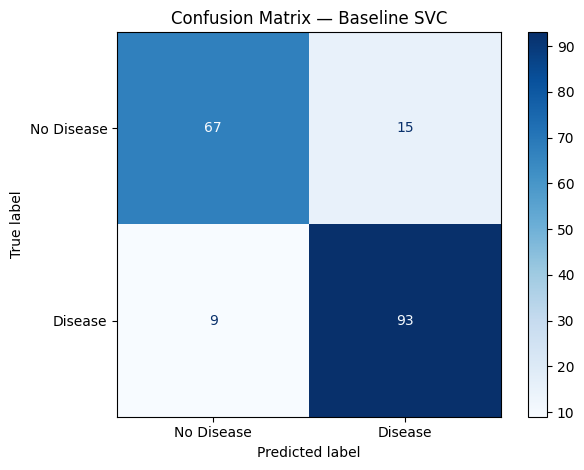

TP:93, TN:67, FN:9, FP:15


In [ ]:
# Plot confusion matrix using baseline SVC predictions
from sklearn.metrics import ConfusionMatrixDisplay

# Re-fit and predict using baseline SVC pipeline
svc_pipe = pipelines["SVC"]
svc_pipe.fit(X_train, y_train)
y_pred_baseline = svc_pipe.predict(X_test)

cm_baseline = confusion_matrix(y_test, y_pred_baseline)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_baseline,
                               display_labels=["No Disease", "Disease"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix — Baseline SVC")
plt.tight_layout()
plt.show()

# Also print the values
TN, FP, FN, TP = cm_baseline[0,0], cm_baseline[0,1], cm_baseline[1,0], cm_baseline[1,1]
print(f"TP:{TP}, TN:{TN}, FN:{FN}, FP:{FP}")

SVC kernel: rbf


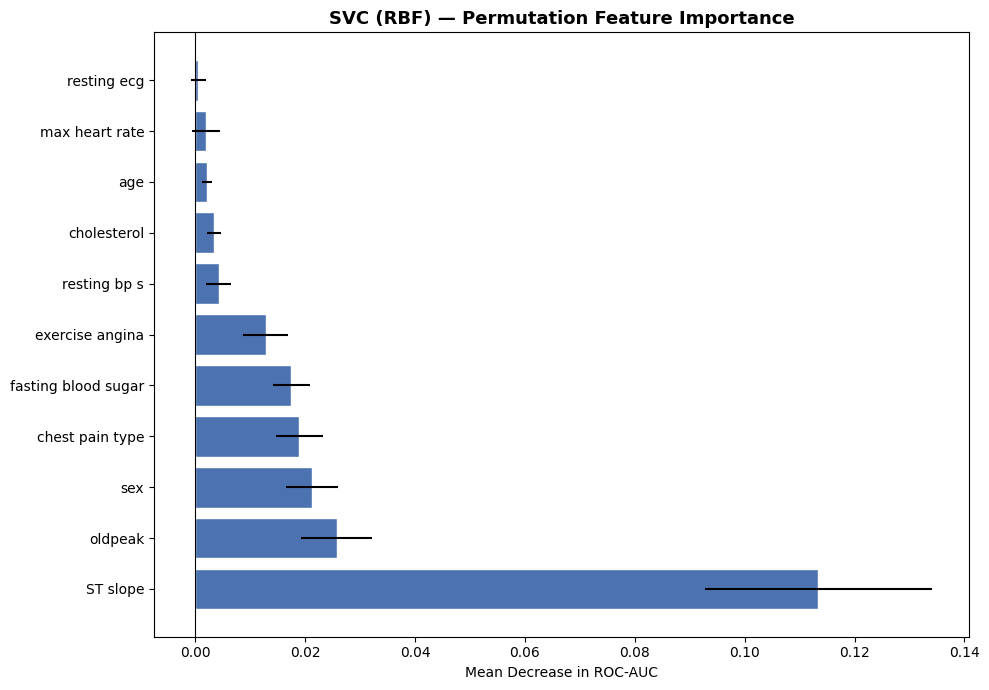


Top 5 most important features:
            Feature  Importance      Std
           ST slope    0.113379 0.020683
            oldpeak    0.025693 0.006481
                sex    0.021210 0.004790
    chest pain type    0.018926 0.004326
fasting blood sugar    0.017480 0.003427


In [ ]:
# 24) Feature importance — SVC
#     Linear kernel: use coefficients
#     RBF kernel: use permutation importance

from sklearn.inspection import permutation_importance

kernel = best_model.named_steps['model'].kernel
print(f"SVC kernel: {kernel}")

if kernel == "linear":
    # Extract feature names after OneHotEncoding
    ohe_features  = (best_model.named_steps['preprocess']
                     .named_transformers_['cat']
                     .get_feature_names_out(categorical).tolist())
    all_features   = continuous + ohe_features
    coefficients   = best_model.named_steps['model'].coef_[0]

    coef_df = pd.DataFrame({
        'Feature':     all_features,
        'Coefficient': coefficients
    }).sort_values('Coefficient', ascending=False)

    plt.figure(figsize=(10, 7))
    colors_bar = ['#DD8452' if c > 0 else '#4C72B0' for c in coef_df['Coefficient']]
    plt.barh(coef_df['Feature'], coef_df['Coefficient'],
             color=colors_bar, edgecolor='white')
    plt.axvline(0, color='black', linewidth=0.8)
    plt.title("SVC (Linear) — Feature Coefficients", fontsize=13, fontweight='bold')
    plt.xlabel("Coefficient Value")
    plt.tight_layout()
    plt.show()

else:
    # RBF kernel — use permutation importance on test set
    result = permutation_importance(
        best_model, X_test, y_test,
        scoring='roc_auc', n_repeats=10, random_state=42, n_jobs=-1
    )
    perm_df = pd.DataFrame({
        'Feature':   X_test.columns,
        'Importance': result.importances_mean,
        'Std':        result.importances_std
    }).sort_values('Importance', ascending=False)

    plt.figure(figsize=(10, 7))
    plt.barh(perm_df['Feature'], perm_df['Importance'],
             xerr=perm_df['Std'], color='#4C72B0', edgecolor='white')
    plt.axvline(0, color='black', linewidth=0.8)
    plt.title("SVC (RBF) — Permutation Feature Importance",
              fontsize=13, fontweight='bold')
    plt.xlabel("Mean Decrease in ROC-AUC")
    plt.tight_layout()
    plt.show()

    print("\nTop 5 most important features:")
    print(perm_df.head(5).to_string(index=False))

In [ ]:
# 25) Save final tuned pipeline model to  project folder
import os

save_dir = '/content/drive/MyDrive/Heart Disease Dataset UCI'
os.makedirs(save_dir, exist_ok=True)

model_path = os.path.join(save_dir, 'heart_disease_model.joblib')
joblib.dump(best_model, model_path)
print(f"Model saved to: {model_path}")

Model saved to: /content/drive/MyDrive/Heart Disease Dataset UCI/heart_disease_model.joblib
